<h1 id="Lecture-5:-Grain,-source-fitness,-and-data-quality">Lecture 5: Grain, source fitness, and data quality</h1><p><strong>Unit:</strong> one hotel booking.  Before calculating a cancellation rate, inspect the row grain, timing, field definitions, and missing coverage.</p>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from ds301.paths import project_root
COURSE_ROOT = project_root()
TEAL, MINT, GOLD, CORAL, INK = "#005F73", "#0A9396", "#E9C46A", "#E76F51", "#1F2933"

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 120, "axes.titleweight": "bold", "axes.spines.top": False, "axes.spines.right": False})
bookings = pd.read_csv(COURSE_ROOT / "data/hotel_bookings.csv", parse_dates=["booking_date"])
bookings.head()

,booking_id,booking_date,lead_time_days,channel,deposit_type,rooms,cancelled
0,30001,2026-04-20,9,corporate,none,1,1
1,30002,2026-01-13,34,direct,refundable,3,0
2,30003,2026-02-17,76,corporate,none,2,1
3,30004,2026-05-15,53,corporate,none,3,1
4,30005,2026-04-06,66,direct,none,2,1


<h2 id="Begin-with-the-records">Begin with the records</h2><p>Each row is one booking, not one guest or room-night. First inspect the fields and when they become known. The later charts summarise these booking records; they cannot repair an unclear unit, an ambiguous definition, or a field that arrives after the prediction moment.</p>

In [2]:
bookings[["booking_id", "booking_date", "lead_time_days", "channel", "deposit_type", "cancelled"]].head(10)

,booking_id,booking_date,lead_time_days,channel,deposit_type,cancelled
0,30001,2026-04-20,9,corporate,none,1
1,30002,2026-01-13,34,direct,refundable,0
2,30003,2026-02-17,76,corporate,none,1
3,30004,2026-05-15,53,corporate,none,1
4,30005,2026-04-06,66,direct,none,1
5,30006,2026-02-13,29,direct,none,0
6,30007,2026-05-23,25,online travel agent,non_refundable,0
7,30008,2026-01-27,25,corporate,refundable,0
8,30009,2026-01-16,61,direct,non_refundable,1
9,30010,2026-05-24,98,online travel agent,non_refundable,1


In [3]:
dictionary = pd.DataFrame({
    "field": ["booking_id", "booking_date", "lead_time_days", "channel", "deposit_type", "cancelled"],
    "meaning": ["unique booking", "recorded booking date", "days before scheduled stay", "booking acquisition route", "deposit policy at booking", "whether this booking later cancelled"],
    "available_at_booking": [True, True, True, True, True, False],
})
dictionary

,field,meaning,available_at_booking
0,booking_id,unique booking,True
1,booking_date,recorded booking date,True
2,lead_time_days,days before scheduled stay,True
3,channel,booking acquisition route,True
4,deposit_type,deposit policy at booking,True
5,cancelled,whether this booking later cancelled,False


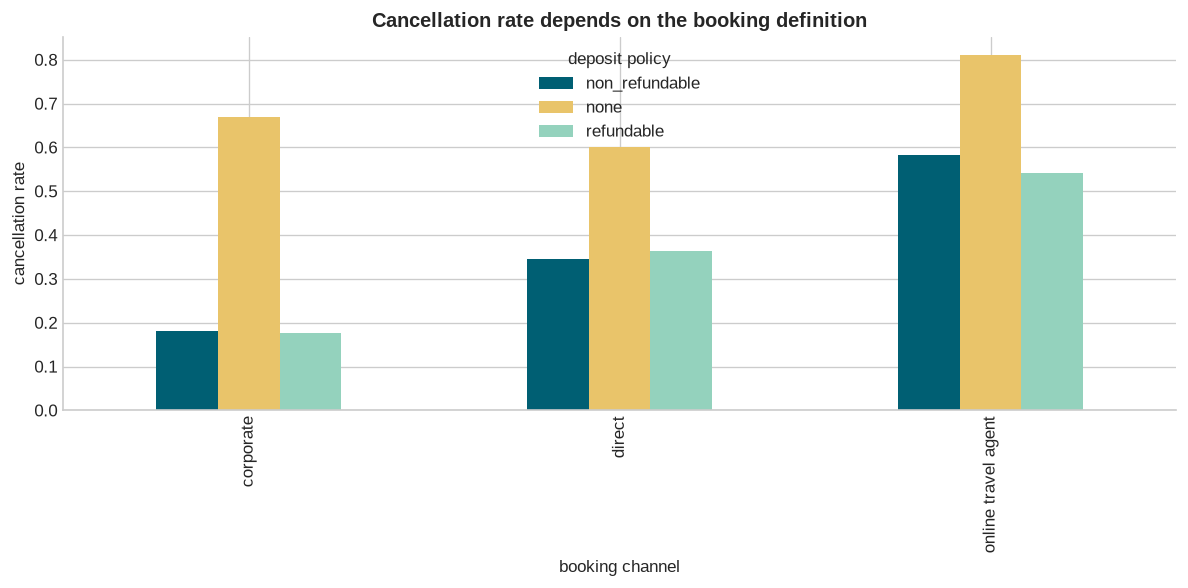

In [4]:
rate = bookings.groupby(["channel", "deposit_type"])["cancelled"].mean().unstack()
fig, ax = plt.subplots(figsize=(10, 5))
rate.plot(kind="bar", ax=ax, color=[TEAL, GOLD, "#94D2BD"])
ax.set(title="Cancellation rate depends on the booking definition", xlabel="booking channel", ylabel="cancellation rate")
ax.legend(title="deposit policy")
plt.tight_layout()

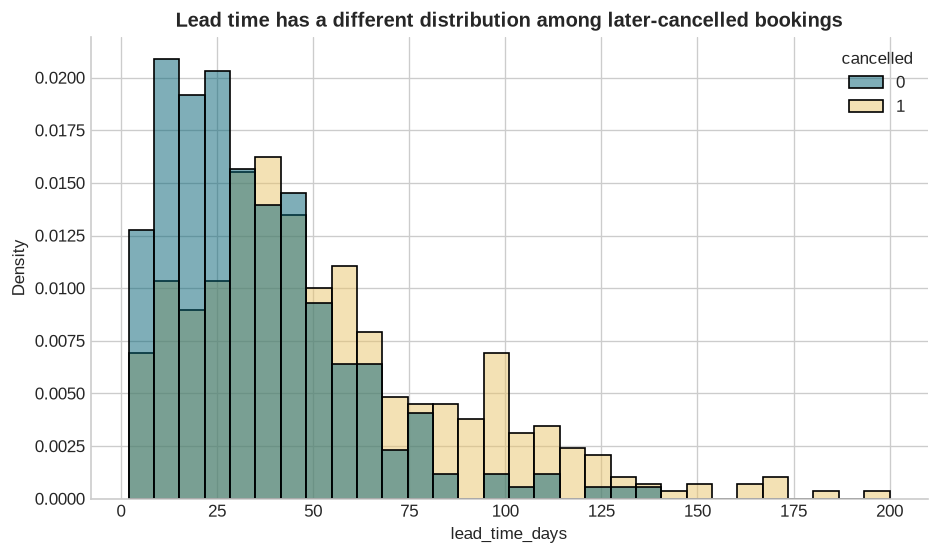

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(bookings, x="lead_time_days", hue="cancelled", bins=30, stat="density", common_norm=False, palette=[TEAL, GOLD], ax=ax)
ax.set(title="Lead time has a different distribution among later-cancelled bookings")
plt.show()

<h2 id="Data-form,-grain,-keys,-and-timing">Data form, grain, keys, and timing</h2><p>A table is a representation, not the business world. Always name what one row represents, how records connect, and when each field becomes true.</p>

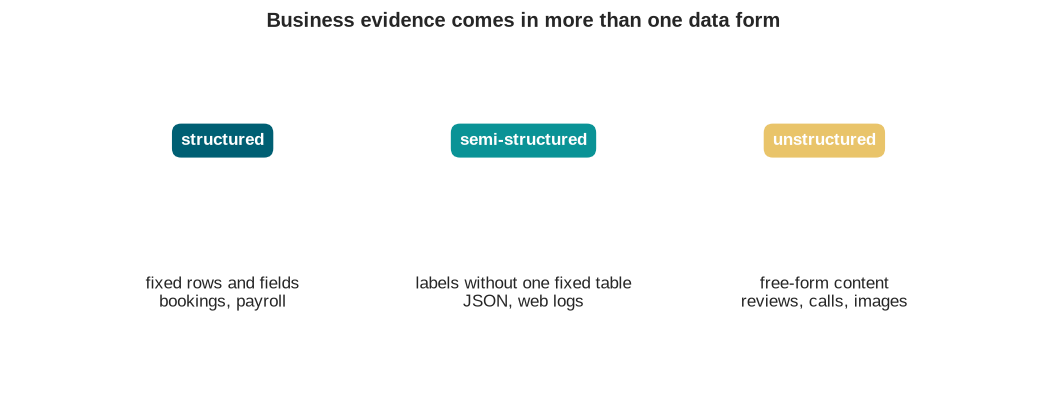

In [6]:
fig, ax=plt.subplots(figsize=(11,3.8))
forms=[("structured","fixed rows and fields","bookings, payroll",TEAL),("semi-structured","labels without one fixed table","JSON, web logs",MINT),("unstructured","free-form content","reviews, calls, images",GOLD)]
for i,(name,meaning,examples,colour) in enumerate(forms):
    ax.text(i,.9,name,ha="center",color="white",weight="bold",bbox=dict(boxstyle="round,pad=.55",fc=colour,ec="none")); ax.text(i,.35,meaning+"\n"+examples,ha="center",va="center")
ax.set(xlim=(-.7,2.7),ylim=(0,1.3),title="Business evidence comes in more than one data form"); ax.axis("off")
plt.show()

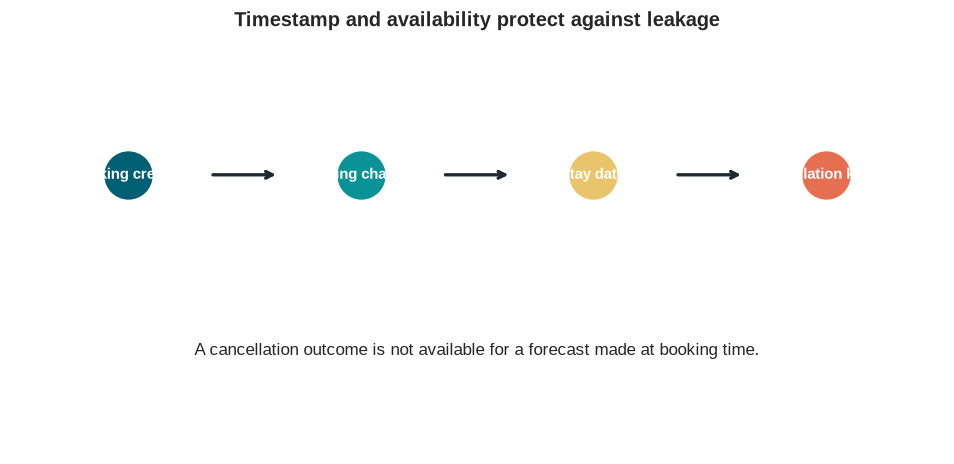

In [7]:
fig,ax=plt.subplots(figsize=(10,4.5))
stages=[("booking created",TEAL),("booking changed",MINT),("stay date",GOLD),("cancellation known",CORAL)]
for i,(label,colour) in enumerate(stages):
    ax.scatter(i,1,s=900,c=colour,edgecolor="white"); ax.text(i,1,label,ha="center",va="center",color="white",weight="bold",fontsize=9)
    if i<3: ax.annotate("",(i+.65,1),(i+.35,1),arrowprops=dict(arrowstyle="->",lw=2,color=INK))
ax.text(1.5,.35,"A cancellation outcome is not available for a forecast made at booking time.",ha="center")
ax.set(xlim=(-.5,3.5),ylim=(0,1.5),title="Timestamp and availability protect against leakage"); ax.axis("off")
plt.show()

<h2 id="Source-fitness-and-data-quality">Source fitness and data quality</h2><p>The best source is fit for a decision, not simply the largest or easiest table. Check coverage, meaning, timeliness, accuracy, permissions, and the population left out.</p>

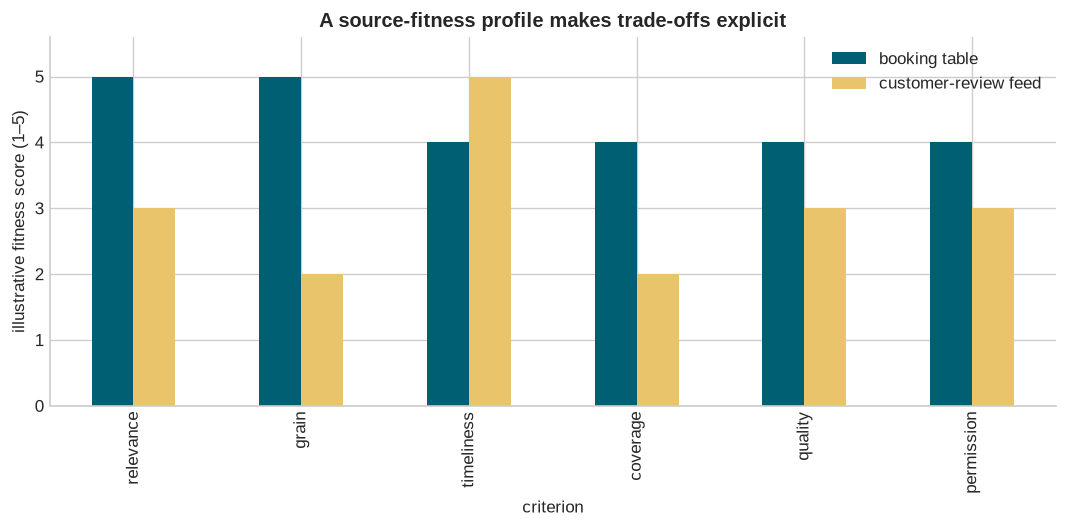

In [8]:
fitness = pd.DataFrame({"criterion":["relevance","grain","timeliness","coverage","quality","permission"],"booking table":[5,5,4,4,4,4],"customer-review feed":[3,2,5,2,3,3]}).set_index("criterion")
fig,ax=plt.subplots(figsize=(9,4.5)); fitness.plot(kind="bar",ax=ax,color=[TEAL,GOLD]); ax.set(ylim=(0,5.6),ylabel="illustrative fitness score (1–5)",title="A source-fitness profile makes trade-offs explicit")
plt.tight_layout()

In [9]:
audit = pd.DataFrame({"missing values":bookings.isna().sum(),"unique values":bookings.nunique(),"type":bookings.dtypes.astype(str)})
audit

,missing values,unique values,type
booking_id,0,700,int64
booking_date,0,174,datetime64[ns]
lead_time_days,0,128,int64
channel,0,3,object
deposit_type,0,3,object
rooms,0,3,int64
cancelled,0,2,int64


<h2 id="Grain-changes-the-question-and-the-answer">Grain changes the question and the answer</h2><p>One booking, one guest, one room-night, and one cancellation event are different units. Do not divide a booking-level numerator by a room-night-level denominator or join records without checking whether each key is unique at the intended grain.</p>

In [10]:
grain = pd.DataFrame({
    "table": ["booking", "room-night", "guest", "cancellation event"],
    "one row represents": ["one reservation", "one booked room on one stay date", "one person linked to a booking", "one cancellation status change"],
    "appropriate question": ["What share of reservations cancel?", "Which stay dates lose the most capacity?", "Which guest segments return?", "When did the cancellation occur?"],
})
grain

,table,one row represents,appropriate question
0,booking,one reservation,What share of reservations cancel?
1,room-night,one booked room on one stay date,Which stay dates lose the most capacity?
2,guest,one person linked to a booking,Which guest segments return?
3,cancellation event,one cancellation status change,When did the cancellation occur?


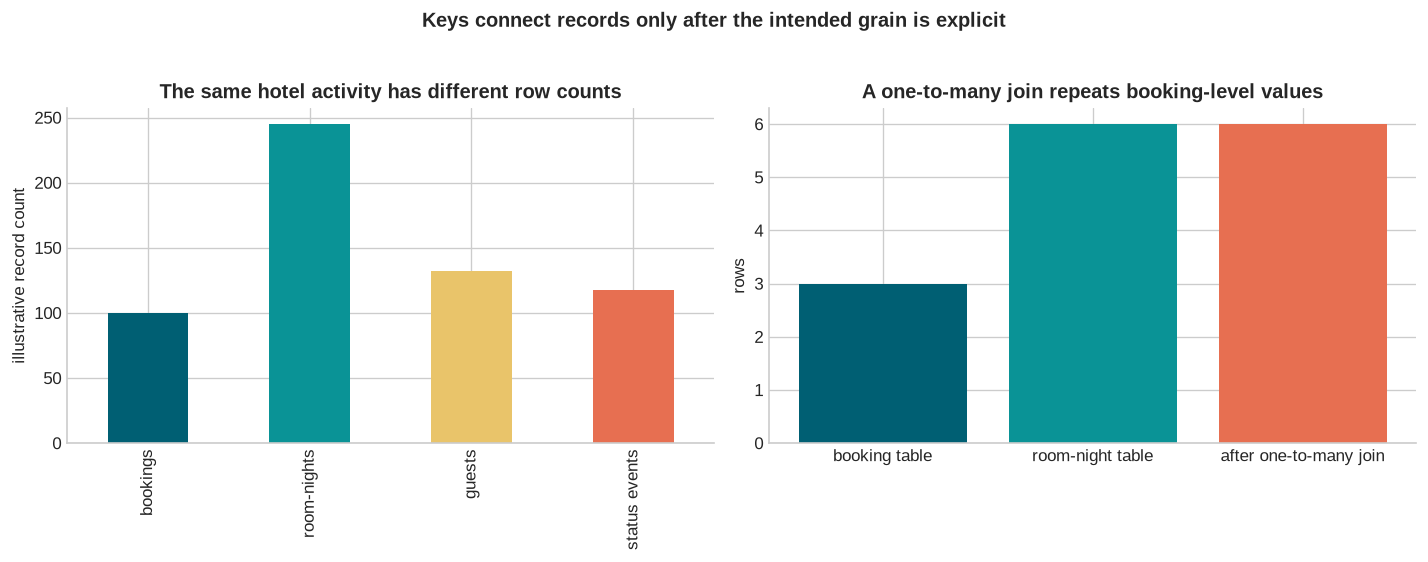

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
booking_counts = pd.Series({"bookings": 100, "room-nights": 245, "guests": 132, "status events": 118})
booking_counts.plot(kind="bar", color=[TEAL, MINT, GOLD, CORAL], ax=axes[0])
axes[0].set(title="The same hotel activity has different row counts", ylabel="illustrative record count", xlabel="")
left = pd.DataFrame({"booking_id": [101, 102, 103], "booking_value": [1, 1, 1]})
right = pd.DataFrame({"booking_id": [101, 101, 102, 103, 103, 103], "room_night": range(1, 7)})
joined = left.merge(right, on="booking_id")
axes[1].bar(["booking table", "room-night table", "after one-to-many join"], [len(left), len(right), len(joined)], color=[TEAL, MINT, CORAL])
axes[1].set(title="A one-to-many join repeats booking-level values", ylabel="rows")
fig.suptitle("Keys connect records only after the intended grain is explicit", weight="bold", y=1.03)
plt.tight_layout()

<h2 id="Internal,-external,-primary,-and-secondary-sources">Internal, external, primary, and secondary sources</h2><p>Source labels describe origin and collection, not automatic quality. An internal operational table may be incomplete; an external contextual source may be relevant only for a clearly stated mechanism.</p>

In [12]:
source_inventory = pd.DataFrame({
    "source": ["booking system", "payment status", "local holiday calendar", "guest survey"],
    "origin": ["internal", "internal", "external", "primary if designed for this study"],
    "recorded for": ["reservation operations", "payment operations", "public calendar", "direct feedback"],
    "useful for": ["booking-level cancellation pattern", "deposit definition", "demand context", "experience not visible in transactions"],
    "caution": ["channel definitions may differ", "availability time must be checked", "association is not proof", "non-response can bias feedback"],
})
source_inventory

,source,origin,recorded for,useful for,caution
0,booking system,internal,reservation operations,booking-level cancellation pattern,channel definitions may differ
1,payment status,internal,payment operations,deposit definition,availability time must be checked
2,local holiday calendar,external,public calendar,demand context,association is not proof
3,guest survey,primary if designed for this study,direct feedback,experience not visible in transactions,non-response can bias feedback


<h2 id="Collect-only-what-can-support-a-legitimate-decision">Collect only what can support a legitimate decision</h2><p>More fields can add cost, privacy risk, and false confidence. Use a field when it has a clear purpose, is proportionate, and can be handled responsibly.</p>

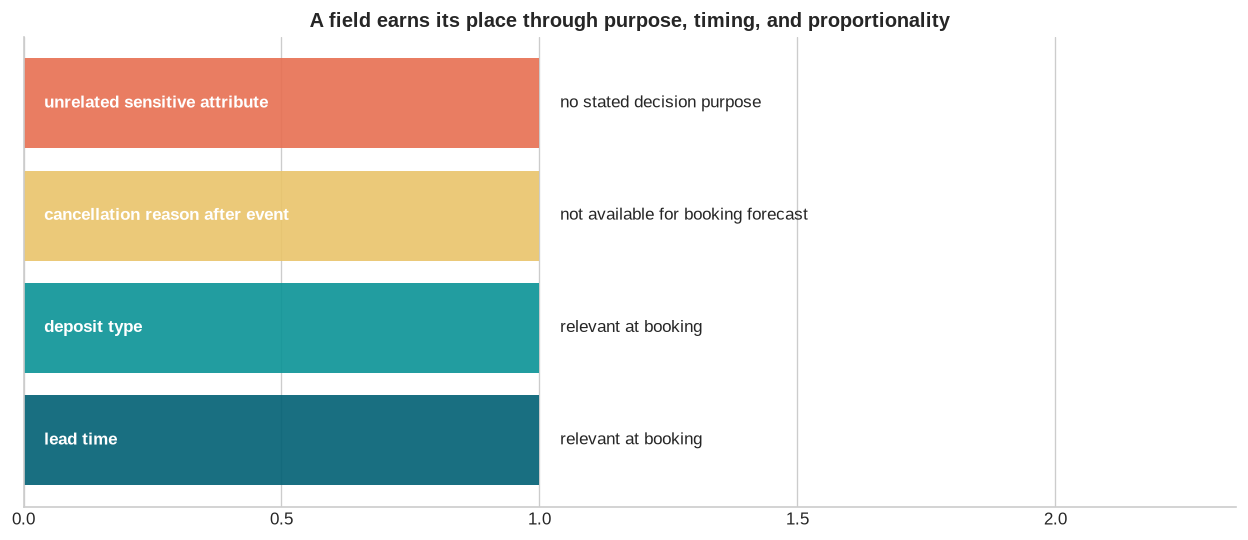

In [13]:
fig, ax = plt.subplots(figsize=(10.5, 4.6))
fields = [
    ("lead time", "relevant at booking", TEAL),
    ("deposit type", "relevant at booking", MINT),
    ("cancellation reason after event", "not available for booking forecast", GOLD),
    ("unrelated sensitive attribute", "no stated decision purpose", CORAL),
]
for i, (field, judgement, colour) in enumerate(fields):
    ax.barh(i, 1, color=colour, alpha=.9)
    ax.text(.04, i, field, va="center", color="white", weight="bold")
    ax.text(1.04, i, judgement, va="center")
ax.set(xlim=(0, 2.35), yticks=[], title="A field earns its place through purpose, timing, and proportionality")
plt.tight_layout()

<h3 id="Student-activity">Student activity</h3><p>State which fields may enter a cancellation forecast made at booking time.  Then identify one field that would cause leakage if it were added after the customer cancels.</p>

<h2 id="Applied-source-lab:-record-grain-changes-the-answer">Applied source lab: record grain changes the answer</h2><p>The Wine Recognition dataset provides one row per analysed wine. Start with these records before asking a class-level question. Aggregating to a class profile is useful for description, but it no longer represents an individual wine.</p>

In [14]:
from sklearn.datasets import load_wine

wine_quality = load_wine(as_frame=True).frame
wine_quality[["alcohol", "color_intensity", "proline", "target"]].head(8)

,alcohol,color_intensity,proline,target
0,14.23,5.64,1065.0,0
1,13.20,4.38,1050.0,0
2,13.16,5.68,1185.0,0
3,14.37,7.80,1480.0,0
4,13.24,4.32,735.0,0
5,14.20,6.75,1450.0,0
6,14.39,5.25,1290.0,0
7,14.06,5.05,1295.0,0


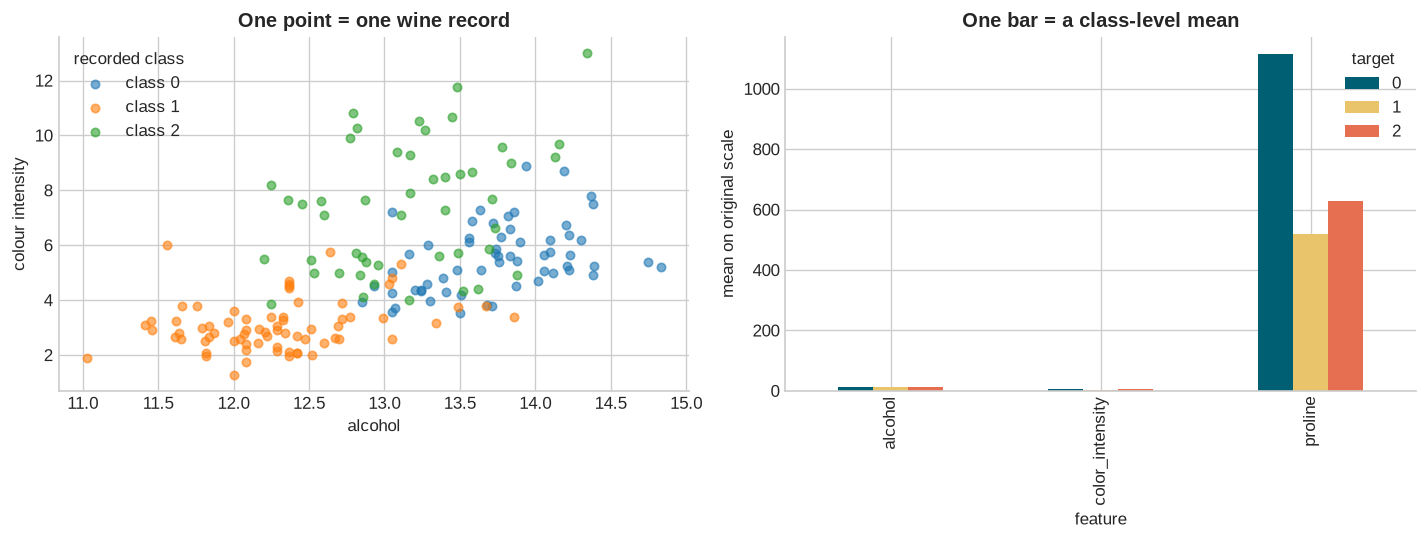

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
for target, group in wine_quality.groupby("target"):
    axes[0].scatter(group.alcohol, group.color_intensity, s=25, alpha=.6, label=f"class {target}")
axes[0].set(title="One point = one wine record", xlabel="alcohol", ylabel="colour intensity"); axes[0].legend(title="recorded class")
profile = wine_quality.groupby("target")[["alcohol", "color_intensity", "proline"]].mean().T
profile.plot(kind="bar", ax=axes[1], color=[TEAL, GOLD, CORAL])
axes[1].set(title="One bar = a class-level mean", xlabel="feature", ylabel="mean on original scale")
plt.tight_layout()

<p>The two panels answer different questions because their grains differ. Write the grain beside each result so that a reader does not treat a group mean as an individual record.</p>

### Lecture application

Check the individual-sample grain, feature units and target provenance. Scaling is a transformation learned on training data. It does not repair measurement error or make a post-outcome field safe.

## Worked project: identifying wine cultivars from measured chemistry

**Question:** can chemical measurements identify the recorded cultivar of an unseen wine sample? The UCI Wine Recognition dataset has 178 measured samples, 13 input features and three cultivar labels. A laboratory could use such a model as a screening aid. This small historical sample cannot establish performance on every producer or future vintage.

We will inspect rows and units, reserve test records, establish a majority-class baseline, select a model using training folds, inspect errors, and write a decision statement. The class label is the outcome, so it never enters the feature matrix. No download is required because scikit-learn bundles these observations.

In [16]:
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, ConfusionMatrixDisplay
project_data = load_wine(as_frame=True)
project_X, project_y = project_data.data, project_data.target
display(project_data.frame.head(8))
display(pd.DataFrame({'dtype':project_X.dtypes.astype(str), 'missing':project_X.isna().sum(),
                      'minimum':project_X.min(), 'maximum':project_X.max()}).round(3))

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
5,14.20,1.76,2.45,15.2,112.0,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450.0,0
6,14.39,1.87,2.45,14.6,96.0,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290.0,0
7,14.06,2.15,2.61,17.6,121.0,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295.0,0


,dtype,missing,minimum,maximum
alcohol,float64,0,11.03,14.83
malic_acid,float64,0,0.74,5.80
ash,float64,0,1.36,3.23
alcalinity_of_ash,float64,0,10.60,30.00
magnesium,float64,0,70.00,162.00
total_phenols,float64,0,0.98,3.88
flavanoids,float64,0,0.34,5.08
nonflavanoid_phenols,float64,0,0.13,0.66
proanthocyanins,float64,0,0.41,3.58
color_intensity,float64,0,1.28,13.00


### Inspect the observations before choosing a model

The scatter compares two recorded features. The counts show how many examples represent each class. A two-feature view may hide separation present in the other measurements. A random stratified split assumes that these records represent the unseen samples of interest; new producers or later vintages would need a different evaluation design.

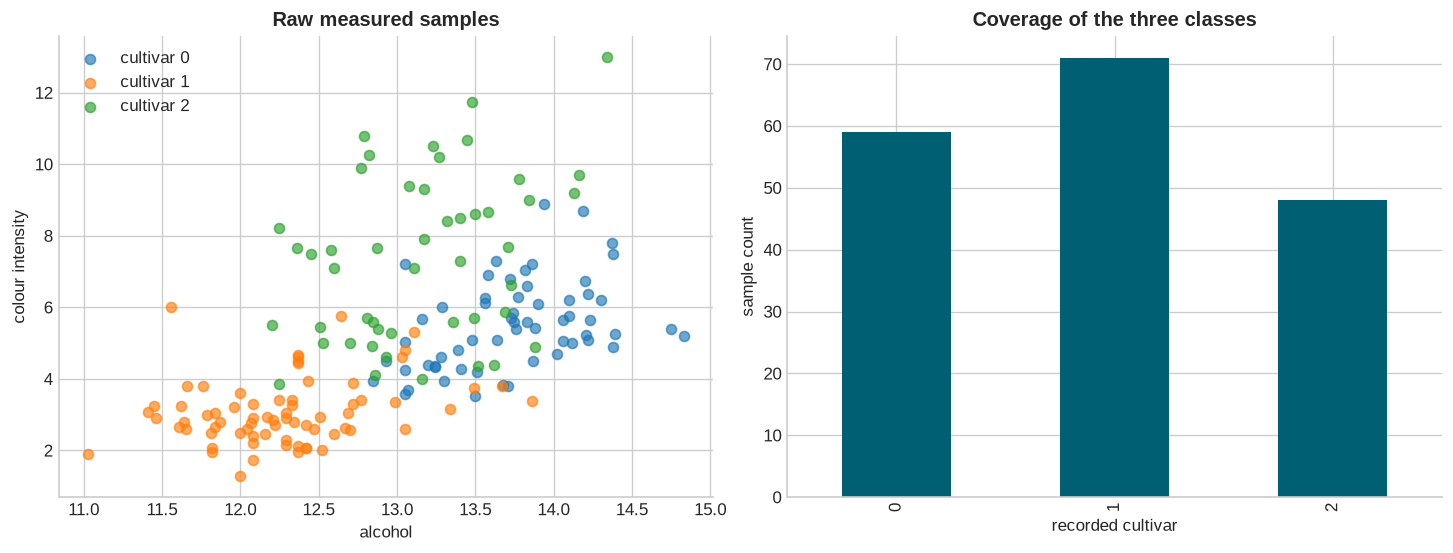

In [17]:
fig, axes = plt.subplots(1,2,figsize=(12,4.5),layout='constrained')
for label in np.unique(project_y):
    selected = project_y==label
    axes[0].scatter(project_X.loc[selected,'alcohol'],project_X.loc[selected,'color_intensity'],label=f'cultivar {label}',alpha=.65)
axes[0].set(xlabel='alcohol',ylabel='colour intensity',title='Raw measured samples'); axes[0].legend()
project_y.value_counts().sort_index().plot.bar(ax=axes[1],color='#005F73')
axes[1].set(xlabel='recorded cultivar',ylabel='sample count',title='Coverage of the three classes'); plt.show()
project_train, project_test, target_train, target_test = train_test_split(project_X,project_y,test_size=.25,stratify=project_y,random_state=301)

### Fit a baseline, then select a model using training folds

The baseline always predicts the most common training class. The learned model scales features inside each training fold and estimates logistic probabilities. The validation table selects the regularisation setting using only training data. `C` is inverse regularisation strength: a smaller value applies stronger shrinkage.

,C,validation balanced accuracy,fold SD
0,0.01,0.981,0.026
1,0.10,0.981,0.026
2,1.00,0.972,0.026
3,10.00,0.964,0.022


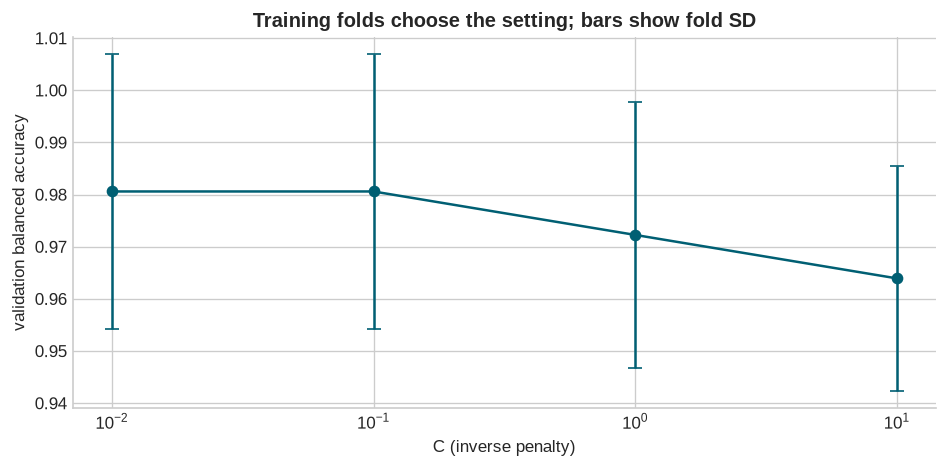

In [18]:
project_baseline = DummyClassifier(strategy='most_frequent').fit(project_train,target_train)
project_cv = StratifiedKFold(5,shuffle=True,random_state=301)
project_search = GridSearchCV(make_pipeline(StandardScaler(),LogisticRegression(max_iter=2000)),
                             {'logisticregression__C':[.01,.1,1,10]},cv=project_cv,scoring='balanced_accuracy')
project_search.fit(project_train,target_train)
cv_table = pd.DataFrame(project_search.cv_results_)[['param_logisticregression__C','mean_test_score','std_test_score']]
display(cv_table.rename(columns={'param_logisticregression__C':'C','mean_test_score':'validation balanced accuracy','std_test_score':'fold SD'}).round(3))
fig,ax=plt.subplots(figsize=(8,4))
ax.errorbar(cv_table.iloc[:,0].astype(float),cv_table.iloc[:,1],yerr=cv_table.iloc[:,2],fmt='o-',capsize=4,color='#005F73')
ax.set(xscale='log',xlabel='C (inverse penalty)',ylabel='validation balanced accuracy',title='Training folds choose the setting; bars show fold SD')
plt.tight_layout(); plt.show()

### Open the held-out set once and inspect the errors

The confusion matrix counts actual outcomes, rather than compressing every error into one score. Each row refers to the true cultivar. Off-diagonal cells show which classes the fitted model confuses. These counts are small, so a high score on this split has substantial sampling uncertainty.

,model,test accuracy,test balanced accuracy
0,majority baseline,0.4,0.333
1,selected logistic model,1.0,1.000


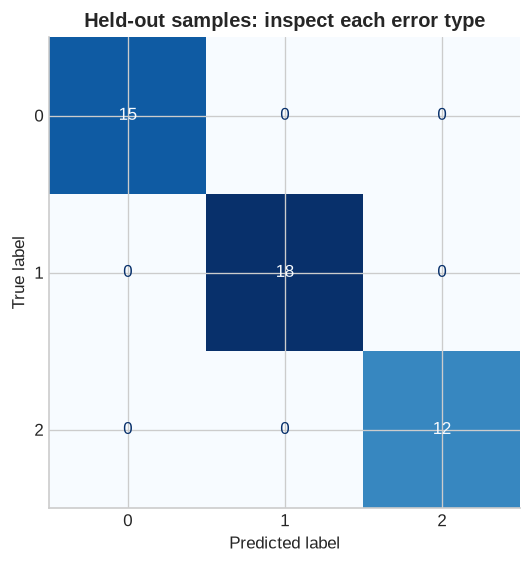

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,observed cultivar,predicted cultivar,highest probability
43,13.24,3.98,2.29,17.5,103.0,2.64,2.63,0.32,1.66,4.36,0.82,3.00,680.0,0,0,0.410
130,12.86,1.35,2.32,18.0,122.0,1.51,1.25,0.21,0.94,4.10,0.76,1.29,630.0,2,2,0.436
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,0,0.490
118,12.77,3.43,1.98,16.0,80.0,1.63,1.25,0.43,0.83,3.40,0.70,2.12,372.0,1,1,0.509
96,11.81,2.12,2.74,21.5,134.0,1.60,0.99,0.14,1.56,2.50,0.95,2.26,625.0,1,1,0.537
121,11.56,2.05,3.23,28.5,119.0,3.18,5.08,0.47,1.87,6.00,0.93,3.69,465.0,1,1,0.540
65,12.37,1.21,2.56,18.1,98.0,2.42,2.65,0.37,2.08,4.60,1.19,2.30,678.0,1,1,0.554
71,13.86,1.51,2.67,25.0,86.0,2.95,2.86,0.21,1.87,3.38,1.36,3.16,410.0,1,1,0.555


In [19]:
project_pred = project_search.predict(project_test)
baseline_pred = project_baseline.predict(project_test)
display(pd.DataFrame({'model':['majority baseline','selected logistic model'],
                      'test accuracy':[accuracy_score(target_test,baseline_pred),accuracy_score(target_test,project_pred)],
                      'test balanced accuracy':[balanced_accuracy_score(target_test,baseline_pred),balanced_accuracy_score(target_test,project_pred)]}).round(3))
fig,ax=plt.subplots(figsize=(6,4.8))
ConfusionMatrixDisplay.from_predictions(target_test,project_pred,ax=ax,cmap='Blues',colorbar=False)
ax.set_title('Held-out samples: inspect each error type'); plt.tight_layout(); plt.show()
project_review=project_test.copy()
project_review['observed cultivar']=target_test
project_review['predicted cultivar']=project_pred
project_review['highest probability']=project_search.predict_proba(project_test).max(axis=1)
display(project_review.sort_values('highest probability').head(8).round(3))

### Decision statement and next evidence

Compare the selected model with the baseline using the table above. State the held-out sample size and the errors you see. A laboratory would next validate new samples from its own measurement process and agree when a prediction requires manual review. Monitoring would track missing measurements, feature ranges, class frequencies, and verified errors. Confidence scores need calibration evidence before they can justify an automatic acceptance threshold.